Multi-Source Data Aggregator
Goal:
Ingest data from 2+ public sources (one CSV, one API), merge them, and produce a summary report with descriptive stats.

Step-by-Step Implementation
1. Fetch CSV — use pandas.read_csv(), inspect with .info(), .head(), handle missing values
2. Fetch API — use requests.get(), parse JSON with .json(), normalize nested structures with pd.json_normalize()
3. Merge 
4. Analyze — compute descriptive stats with .describe(), group with .groupby().agg(), maybe a simple correlation
5. Output — save results to a clean summary CSV + a Jupyter Notebook with markdown cells explaining each step


## Setup


In [103]:
import pandas as pd 
import requests
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Fetch CSV Data


In [104]:
csv_file_df_1 = pd.read_csv("world_bank_folder/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_2448.csv", skiprows=4)
csv_file_df_1.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30654.485124,22664.370995,26827.344787,31000.571380,34897.618393,38590.565029,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089515,186.909365,197.367876,225.400456,208.963066,226.836513,...,1529.923080,1553.617944,1508.031525,1351.503167,1560.894626,1675.902524,1571.132704,1628.227289,1722.385620,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,416.871146,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.551510,155.587905,...,1577.203497,1723.114463,2219.412555,2034.437940,2116.938294,2143.072094,1846.246811,1416.228412,1600.058374,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2832.149980,2891.830324,2507.868072,1749.179484,2266.968349,3598.536691,2885.513491,2720.819007,3129.476623,NaN


## 2. Transform: Wide to Long


In [105]:
melted_csv_df = csv_file_df_1.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=[str(x) for x in range(1960, 2026)],
    var_name="Year", value_name="GDP_per_capita"
)
melted_csv_df["Year"] = melted_csv_df["Year"].astype(int)
melted_csv_df


,Country Name,Country Code,Indicator Name,Indicator Code,Year,GDP_per_capita
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.089515
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,121.936832
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN
...,...,...,...,...,...,...
17485,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,7899.418411
17486,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,NaN
17487,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,6597.714509
17488,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,1317.877716


## 3. Fetch API Data


In [106]:
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("RESTCOUNTRIES_KEY")

all_countries = []
offset = 0

while True:
    resp = requests.get(
        f"https://api.restcountries.com/countries/v5?limit=100&offset={offset}&response_fields=names.common,codes.alpha_3,region,subregion,continents,population,landlocked,area.kilometers",
        headers={"Authorization": f"Bearer {api_key}"}
    )
    body = resp.json()
    countries = body["data"]["objects"]
    if not countries:
        break
    all_countries.extend(countries)
    offset += 100

api_df = pd.json_normalize(all_countries)
api_df.rename(columns={'names.common': 'Country', 'codes.alpha_3': 'Country Code'}, inplace=True)


api_df.head()


,region,subregion,continents,landlocked,population,Country,Country Code,area.kilometers,_meta.lastUpdatedTimestamp
0,Asia,Western Asia,[Asia],False,244000,Abkhazia,,8665.0,1783005246
1,Asia,Southern Asia,[Asia],True,35000000,Afghanistan,AFG,652230.0,1783005246
2,Europe,Southeast Europe,[Europe],False,2402113,Albania,ALB,28748.0,1783005246
3,Africa,Northern Africa,[Africa],False,47400000,Algeria,DZA,2381741.0,1783005246
4,Oceania,Polynesia,[Oceania],False,43268,American Samoa,ASM,199.0,1783005246


In [107]:
print(f"melted_csv_df columns:{melted_csv_df.columns.tolist()}")
print(f"api_df columns:{api_df.columns.tolist()}")


#melted_csv_df  api_df

#Country Name -> Country
#Country Code -> Country Code

melted_csv_df columns:['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', 'Year', 'GDP_per_capita']
api_df columns:['region', 'subregion', 'continents', 'landlocked', 'population', 'Country', 'Country Code', 'area.kilometers', '_meta.lastUpdatedTimestamp']


## 4. Merge Datasets


In [108]:
api_df.drop(columns=["_meta.lastUpdatedTimestamp"], inplace=True)
api_df.rename(columns={"area.kilometers": "area_km2", "Country": "Country Name"}, inplace=True)


merged = melted_csv_df.merge(api_df, on=["Country Code", "Country Name"], how="left")

# Flatten continents list to string (required for groupby)
merged["continents"] = merged["continents"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)

merged


,Country Name,Country Code,Indicator Name,Indicator Code,Year,GDP_per_capita,region,subregion,continents,landlocked,population,area_km2
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN,Americas,Caribbean,North America,False,108880.0,180.0
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,186.089515,NaN,NaN,None,None,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN,Asia,Southern Asia,Asia,True,35000000.0,652230.0
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,121.936832,NaN,NaN,None,None,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,1960,NaN,Africa,Middle Africa,Africa,False,36604681.0,1246700.0
...,...,...,...,...,...,...,...,...,...,...,...,...
17485,Kosovo,XKX,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,7899.418411,NaN,NaN,None,None,NaN,NaN
17486,"Yemen, Rep.",YEM,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,NaN,NaN,NaN,None,None,NaN,NaN
17487,South Africa,ZAF,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,6597.714509,Africa,Southern Africa,Africa,False,63015904.0,1221037.0
17488,Zambia,ZMB,GDP per capita (current US$),NY.GDP.PCAP.CD,2025,1317.877716,Africa,Eastern Africa,Africa,True,20216029.0,752612.0


## 5. Analysis


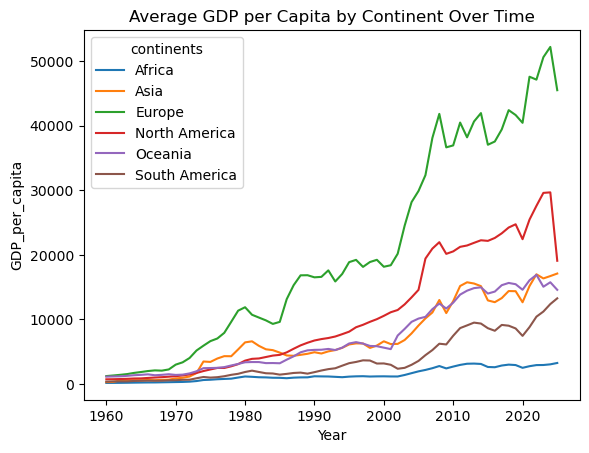

In [109]:
trend = merged.groupby(["Year", "continents"])["GDP_per_capita"].mean().reset_index()
sns.lineplot(data=trend, x="Year", y="GDP_per_capita", hue="continents")
plt.title("Average GDP per Capita by Continent Over Time")
plt.show()


In [110]:
latest = merged[merged["Year"] == merged["Year"].max()]
top10 = latest.nlargest(10, "GDP_per_capita")[["Country Name", "GDP_per_capita", "continents"]]
bottom10 = latest.nsmallest(10, "GDP_per_capita")[["Country Name", "GDP_per_capita", "continents"]]
print("Top 10 richest countries (" + str(int(merged["Year"].max())) + "):")
display(top10)
print("\nTop 10 poorest countries (" + str(int(merged["Year"].max())) + "):")
display(bottom10)


Top 10 richest countries (2025):


,Country Name,GDP_per_capita,continents
17368,Luxembourg,147252.179122,Europe
17335,Ireland,131592.462548,Europe
17262,Switzerland,114769.012314,Europe
17432,Singapore,98813.978817,Asia
17338,Iceland,98323.484952,Europe
17401,Norway,94594.192957,Europe
17475,United States,90026.516301,North America
17394,North America,86308.071727,None
17283,Denmark,76970.153522,Europe
17370,"Macao SAR, China",75901.746129,None



Top 10 poorest countries (2025):


,Country Name,GDP_per_capita,continents
17241,Burundi,233.823013,Africa
17259,Central African Republic,556.131398,Africa
17375,Madagascar,599.265294,Africa
17389,Mozambique,626.914419,Africa
17437,"Somalia, Fed. Rep.",661.173878,None
17392,Malawi,671.506847,Africa
17397,Niger,775.353622,Africa
17268,"Congo, Dem. Rep.",806.776001,None
17360,Low income,837.360635,None
17434,Sierra Leone,846.296172,Africa


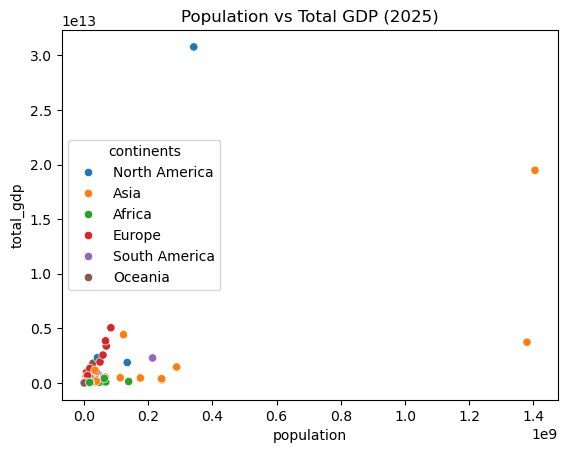

In [112]:
merged["total_gdp"] = merged["GDP_per_capita"] * merged["population"]
sns.scatterplot(data=merged[merged["Year"] == 2025], x="population", y="total_gdp", hue="continents")
plt.title("Population vs Total GDP (2025)")
plt.show()
